$$P = G\left\{ k_B T_{N} + \frac{k_B T}{2}\left[\left( \frac{eV_{audio}(t) + hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{audio}(t) + hf_{RF}}{2k_B T}\right)} + \left( \frac{eV_{audio}(t) - hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{audio}(t) - hf_{RF}}{2k_B T}\right)}\right]\right\}$$


$$P = G\left\{k_B T_{N} + \frac{k_B T}{2}\left[\left( \frac{e V_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)} + \left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)}\right]\right\}$$

$$P = G\left\{k_B T_{N} + \frac{k_B T}{2}\left[\textbf{xcothx}{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)} + \textbf{xcothx}{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)}\right]\right\}$$

$$P(t,\phi,\eta,\theta,\psi,\theta_N,G) = G\left\{\theta_N + \frac{\theta}{2}\left[\textbf{xcothx}{\left( \frac{\eta\sin{(2\pi f_{audio} t  + \psi_{audio})} + \phi}{2\theta}\right)} + \textbf{xcothx}{\left( \frac{\eta\sin{(2\pi f_{audio} t  + \psi_{audio})} - \phi}{2\theta}\right)}\right]\right\}$$

$k_B T$ is in units of pixels. P is in units of pixels. G is dimensionless linear gain. $eV_{audio}$ is in units of pixels. hf is in units of pixels.  In reduced form, $\theta = k_B T$, $\phi = hf_{RF}$, and $\eta = eV^{audio}_{peak}$, all measured in units of pixels with the same conversion between pixels and yoctojoules.



In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import time

In [5]:
def xcothx1(x):
    if x == 0:
        return 1
    else:
        return x/np.tanh(x)
xcothx = np.frompyfunc(xcothx1, 1, 1)#https://numpy.org/doc/stable/reference/generated/numpy.frompyfunc.html#numpy.frompyfunc


In [42]:
def xcothx2(x):
    return x/np.tanh(x)

In [47]:
def p_of_t(t,photon_energy,thermal_energy,peak_audio_energy,audio_period,audio_phase,noise_energy,gain):
    return gain*(noise_energy + 0.5*thermal_energy*(xcothx((peak_audio_energy*np.sin((2*np.pi*t/audio_period) + (np.pi*audio_phase/180)) + photon_energy)/(2*thermal_energy)) + xcothx((peak_audio_energy*np.sin((2*np.pi*t/audio_period) + (np.pi*audio_phase/180)) - photon_energy)/(2*thermal_energy))))

(0.0, 1000.0)

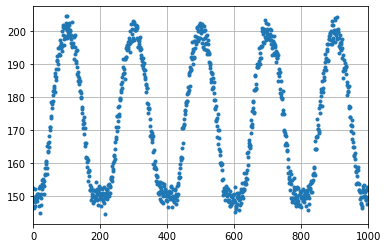

In [50]:
photon_energy = 100
thermal_energy = 10
peak_audio_energy = 200
audio_period = 400
audio_phase = 0
noise_energy = 100
sigma = 2
gain = 1
timewave = np.arange(0,1000,1.0)
noisewave = p_of_t(timewave,photon_energy,thermal_energy,peak_audio_energy,audio_period,audio_phase,noise_energy,gain) + np.random.normal(0, sigma, len(timewave))
plt.plot(timewave,noisewave,'.')
plt.grid()
plt.xlim(0,len(timewave))

In [51]:
popt, pcov = curve_fit(p_of_t, timewave, noisewave)


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

error: Result from function call is not a proper array of floats.

In [34]:
def sin2f(t,psi,offset,peak,period):
    return offset + peak*np.sin((np.pi*psi/180) + (4*np.pi*t/period))


In [58]:
popt, pcov = curve_fit(sin2f, timewave, noisewave)


In [59]:
popt

array([ 8.75236887e+01, -1.94009552e+03,  2.11311114e+03,  9.99993127e-01])

In [38]:
0.00001/np.tanh(0.00001)

1.0000000000333333

In [56]:
timewave

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

In [57]:
noisewave

array([152.39894287967795, 149.84963804884927, 146.41797785573922,
       148.82396556665626, 148.2220284455591, 147.0973963932262,
       152.02017545946296, 149.0550034231912, 150.14078326274773,
       149.20869782659332, 148.41612795033353, 149.3006754873775,
       150.6509135176823, 149.99649020285443, 150.62472338741566,
       150.5650105037408, 147.01294356125516, 150.1730428207669,
       152.5533116381326, 144.97904341473946, 152.996174315198,
       149.69849878872205, 147.2139333967757, 149.30631127960498,
       150.65157243743002, 152.27308314765136, 154.9895766167519,
       153.59326650972483, 155.27083145896438, 153.7577272201456,
       153.09202723588115, 152.95453612994203, 150.65951100570834,
       154.60612595526882, 158.49630444445464, 156.3741027026485,
       156.6852660184083, 160.26681666125475, 159.6943755922879,
       160.65525992643896, 158.63473038052322, 156.5510350887509,
       165.07545992281004, 163.2539084218866, 163.5235045349291,
       165.920